# Recommender System

🎯 **Goal**: Build a simple, practical recommender system that suggests board games based on user preferences

We start from a dataset of board games and user ratings (BoardGameGeek).

Rather than relying on game features (mechanics, themes, etc.), this notebook uses collaborative filtering — learning from patterns in how users rate games.

In practice, that means:

- Finding games that are liked by similar groups of users
- Using those relationships to generate recommendations
- Testing how well this works across different types of users

The focus is on building something simple, interpretable, and product-relevant, rather than over-optimising the model.

### Executive summary

- Built an item-based collaborative filtering recommender
- Recommendations adapt to different user types (niche, typical, hobbyist)
- Personalised results differ meaningfully from a popularity baseline (~25% overlap for a hobbyist user)
- Clear trade-off between precision (niche, focused) and coverage (broad, varied)

👉 Overall: collaborative filtering provides a strong foundation for recommendations, with clear paths to improve via hybrid models and product-layer controls.

### Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

## Load data

In [2]:
# Load ratings df (core data set for recommender)
DATA_DIR = Path("../raw_data")

ratings = pd.read_csv(DATA_DIR / "user_ratings.csv")
ratings.head()

,BGGId,Rating,Username
0,213788,8.0,Tonydorrf
1,213788,8.0,tachyon14k
2,213788,8.0,Ungotter
3,213788,8.0,brainlocki3
4,213788,8.0,PPMP


In [3]:
# Load games df with core data only
games = pd.read_csv(DATA_DIR / "games.csv")
games_clean = games[["BGGId", "Name", "NumUserRatings"]].copy()

games_clean.head()


,BGGId,Name,NumUserRatings
0,1,Die Macher,5354
1,2,Dragonmaster,562
2,3,Samurai,15146
3,4,Tal der Könige,340
4,5,Acquire,18655


In [4]:
# Check for duplicates in games
games_clean["BGGId"].duplicated().sum()

np.int64(0)

In [5]:
# Check for missing values in games
games_clean.isnull().sum()

BGGId             0
Name              0
NumUserRatings    0
dtype: int64

## Explore Ratings data

In [6]:
ratings.shape

(18942215, 3)

In [7]:
# Check for duplicates
ratings.duplicated().sum()

np.int64(0)

In [8]:
# Check for missing values
ratings.isna().sum().sort_values(ascending=False)

Username    63
BGGId        0
Rating       0
dtype: int64

In [9]:
# Basic counts
n_users = ratings["Username"].nunique()
n_games = ratings["BGGId"].nunique()
n_ratings = len(ratings)

print(f"Unique users: {n_users:,}")
print(f"Unique games rated: {n_games:,}")
print(f"Total ratings: {n_ratings:,}")

Unique users: 411,374
Unique games rated: 21,925
Total ratings: 18,942,215


In [10]:
# DECISION: Drop 63 rows with missing usernames (vs 411k unique users)
ratings = ratings.dropna(subset=["Username"])

In [11]:
# Average ratings per user and game
ratings_per_user = ratings.groupby("Username")["BGGId"].count()
ratings_per_game = ratings.groupby("BGGId")["Username"].count()

print("\nRatings per user:")
print(ratings_per_user.describe())

print("\nRatings per game:")
print(ratings_per_game.describe())


Ratings per user:
count    411374.000000
mean         46.046060
std         108.431797
min           1.000000
25%           2.000000
50%          12.000000
75%          44.000000
max        6493.000000
Name: BGGId, dtype: float64

Ratings per game:
count     21925.000000
mean        863.952201
std        3627.070586
min           7.000000
25%          57.000000
50%         125.000000
75%         398.000000
max      107760.000000
Name: Username, dtype: float64


In [12]:
# Sparsity estimate: How many possible ratings are we missing?
possible_ratings = n_users * n_games
sparsity = 1 - (n_ratings / possible_ratings)

print(f"\nApproximate matrix sparsity: {sparsity:.1%}")


Approximate matrix sparsity: 99.8%


### 🙋‍♀️ Ratings Data – Initial Assessment

The ratings dataset is large and high quality, with ~19M ratings across ~411k users and ~22k games. 

User activity is highly skewed: while the mean number of ratings per user is ~46, the median is 12, indicating a long tail of casual users alongside a smaller group of highly active users. A similar pattern exists for games, with a median of 125 ratings but some games exceeding 100k ratings.

The user–item matrix is extremely sparse (~99.8%), which is expected for recommender systems. Despite this, there is enough overlap in user behaviour (multiple ratings per user and per game) to support collaborative filtering.

**So what?**

The data is well-suited to an item-based collaborative filtering approach. 

However, the long tail of low-activity users and low-rated games is likely to introduce noise. As a result, the next step is to filter the dataset to retain only:

- users with a minimum number of ratings (e.g. ≥10)
- games with a minimum number of ratings (e.g. ≥20)

This will reduce sparsity, improve the reliability of similarity calculations, and lead to more meaningful recommendations.

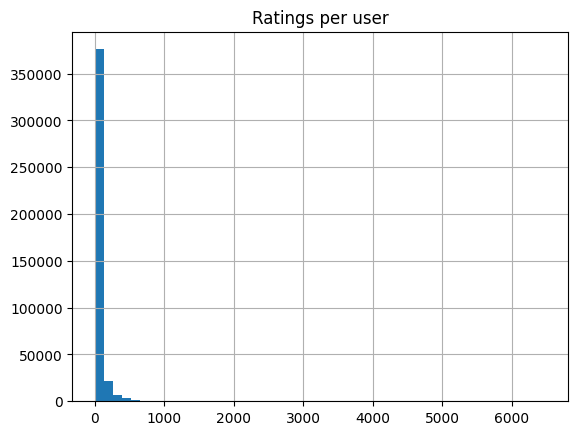

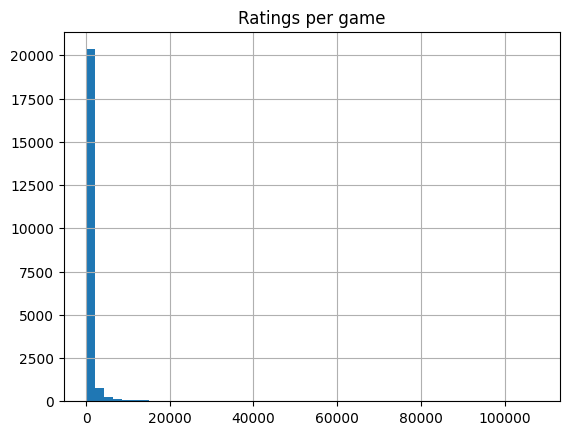

In [13]:
# ---- Visualise distributions ----

# Ratings per user
ratings_per_user.hist(bins=50)
plt.title("Ratings per user")
plt.show()

# Ratings per games
ratings_per_game.hist(bins=50)
plt.title("Ratings per game")
plt.show()


In [14]:
# Check key percentiles
ratings_per_user.quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25      2.0
0.50     12.0
0.75     44.0
0.90    115.0
0.95    198.0
Name: BGGId, dtype: float64

In [15]:
ratings_per_game.quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25      57.0
0.50     125.0
0.75     398.0
0.90    1481.6
0.95    3228.6
Name: Username, dtype: float64

In [16]:
# Set recommended thresholds
min_user_ratings = 10
min_game_ratings = 50

# ----- Check impact of thresholds -----

# Filter active users
active_users = ratings_per_user[ratings_per_user >= min_user_ratings].index
ratings_filtered = ratings[ratings["Username"].isin(active_users)]

# Filter popular games
popular_games = ratings_filtered["BGGId"].value_counts()
popular_games = popular_games[popular_games >= min_game_ratings].index

# Combine
ratings_filtered = ratings_filtered[ratings_filtered["BGGId"].isin(popular_games)]

# Check
retained = len(ratings_filtered) / len(ratings)

print("Original ratings:", len(ratings))
print("Filtered ratings:", len(ratings_filtered))
print(f"Retained: {retained:.2%}")

print("Users:", ratings_filtered["Username"].nunique())
print("Games:", ratings_filtered["BGGId"].nunique())

Original ratings: 18942152
Filtered ratings: 18194617
Retained: 96.05%
Users: 224604
Games: 17165


## User-item matrix

Allows us to compare games based on how users rated them, and compare users based on what they liked.

In [17]:
# One row per user, one column per game, ratings inside the matrix
user_item_matrix = ratings_filtered.pivot_table(
    index="Username",
    columns="BGGId",
    values="Rating",
    aggfunc="mean" # how to combine multiple ratings from one user
)

print(user_item_matrix.shape)
user_item_matrix.iloc[:5, :5]

/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_32350/1549050647.py:2: PerformanceWarning: The following operation may generate 3855327660 cells in the resulting pandas object.
  user_item_matrix = ratings_filtered.pivot_table(


(224604, 17165)


BGGId,1,2,3,4,5
Username,,,,,
mycroft,NaN,NaN,NaN,NaN,8.0
-=Yod@=-,NaN,NaN,NaN,NaN,NaN
-Johnny-,5.0,NaN,4.0,NaN,7.0
-Loren-,NaN,NaN,NaN,NaN,NaN
-LucaS-,NaN,NaN,NaN,NaN,NaN


In [18]:
# Do some users now have zero ratings post filtering?
empty_users = user_item_matrix.isna().all(axis=1).sum()
empty_users

np.int64(0)

🙋‍♀️ Given the size of the matrix (over 3 billion cells), we'll work with a smaller group of top-rated games to get this working well first...

In [19]:
# Define subset
top_5k_games = (ratings_filtered["BGGId"].value_counts().head(5000).index)

# Filter to subset
ratings_small = ratings_filtered[ratings_filtered["BGGId"].isin(top_5k_games)].copy()

print("Subset shape:", ratings_small.shape)
print("Unique games:", ratings_small["BGGId"].nunique())

Subset shape: (16325573, 3)
Unique games: 5000


In [20]:
# Build smaller user-item matrix
user_item_matrix_small = ratings_small.pivot_table(
    index="Username",
    columns="BGGId",
    values="Rating",
    aggfunc="mean"
)

print(user_item_matrix.shape)

(224604, 17165)


In [21]:
# ----- Prepare for item-item similarity -----

# Transpose -> rows = games, columns = users
item_user_matrix = user_item_matrix_small.T

# Fill NaN with 0 to enable calculations
item_user_matrix = item_user_matrix.fillna(0)

item_user_matrix.shape

(5000, 224544)

In [22]:
# Compute cosine similarity
item_similarity = cosine_similarity(item_user_matrix)

# Convert to dataframe with rows and columns as game IDs
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.shape

(5000, 5000)

In [23]:
# ----- Check results -----

# Pick an example game
example_game = item_similarity_df.index[0]

# Show 10most similar games
similar_games = (item_similarity_df[example_game].sort_values(ascending=False).head(10))

similar_games.to_list()

[0.999999999999954,
 0.3694471646268327,
 0.36255091985642107,
 0.35345352752669057,
 0.3502652050873121,
 0.3477269012418889,
 0.34401834703851963,
 0.3394767995287788,
 0.3248568322887566,
 0.3246135947107317]

In [ ]:
# ----- Add game names for readability -----

# Create lookup
bggid_to_name = dict(zip(games_clean["BGGId"], games_clean["Name"]))

# Remove original games from similar game set
similar_games = similar_games.drop(index=example_game)

# Convert to dataframe
similar_df = pd.DataFrame({
    "BGGId": similar_games.index,
    "Score": similar_games.values
})

# Map names
similar_df["Name"] = similar_df["BGGId"].map(bggid_to_name)

similar_df[["Name", "Score"]]

,Name,Score
0,Age of Steam,0.369447
1,Goa,0.362551
2,Taj Mahal,0.353454
3,Imperial,0.350265
4,The Princes of Florence,0.347727
5,Amun-Re,0.344018
6,Indonesia,0.339477
7,Ra,0.324857
8,Automobile,0.324614


In [ ]:
# Get the name of the example game
example_name = bggid_to_name.get(example_game, "Unknown")

print(f"Similar to: {example_name}")
similar_df[["Name", "Score"]]

Similar to: Die Macher


,Name,Score
0,Age of Steam,0.369447
1,Goa,0.362551
2,Taj Mahal,0.353454
3,Imperial,0.350265
4,The Princes of Florence,0.347727
5,Amun-Re,0.344018
6,Indonesia,0.339477
7,Ra,0.324857
8,Automobile,0.324614


In [27]:
# Test with a more mainstream game
games_clean[games_clean["Name"].str.contains("Wingspan", case=False, na=False)]

,BGGId,Name,NumUserRatings
19608,266192,Wingspan,54404


In [28]:

# Define WingSpan ID
wingspan_game = 266192

similar_to_wingspan = (item_similarity_df[wingspan_game].sort_values(ascending=False).head(10))

similar_to_wingspan = similar_to_wingspan.drop(wingspan_game)

# Convert to DataFrame
wingspan_df = pd.DataFrame({
    "BGGId": similar_to_wingspan.index,
    "Score": similar_to_wingspan.values
})

# Add game names
bggid_to_name = dict(zip(games_clean["BGGId"], games_clean["Name"]))
wingspan_df["Name"] = wingspan_df["BGGId"].map(bggid_to_name)

print("Similar to: WingSpan")
wingspan_df[["Name", "Score"]]

Similar to: WingSpan


,Name,Score
0,Azul,0.549159
1,Terraforming Mars,0.527954
2,Everdell,0.495875
3,The Quacks of Quedlinburg,0.486587
4,Scythe,0.482292
5,7 Wonders Duel,0.477327
6,Viticulture Essential Edition,0.468371
7,Sagrada,0.432760
8,Codenames,0.429195


#### 💡 Reflection: Item-Based Collaborative Filtering

An item-based collaborative filtering model was created that identifies similar games based on shared user rating patterns, without using explicit game features.

Initial results show strong, coherent recommendations. For example, querying for Wingspan returns a mix of medium-weight strategy and engine-building games (e.g. Terraforming Mars, Everdell, Viticulture), alongside some lighter but widely played titles (e.g. Azul, Codenames). This suggests the model is capturing both mechanical similarity and shared audience preferences.

Similarity scores are relatively modest (~0.3–0.5), which is expected given the sparsity of the data. In this context, the ranking and coherence of recommendations are more important than absolute values.

A key observation is a mild popularity bias - Widely rated games appear more frequently due to stronger interaction signals. This can be beneficial in reinforcing reliable, high-confidence recommendations, though it may reduce exposure to more niche titles.

*Rather than treating this purely as a flaw, it may be better seen as a product trade-off: some users will value familiar, high-confidence recommendations, while others may prefer more niche discovery. This could be addressed through simple controls, such as allowing users to explore more “hidden gem” recommendations.*

## A User-level Recommender

Instead of "What is similar to this one game?", ask "Given the games this user liked, what else should we recommend?

In [ ]:
# ----- Choose a test user -----

# Select most active user in the subset
user_ratings_counts = ratings_small["Username"].value_counts()
example_user = user_ratings_counts.index[0]

# Use user-item matrix (users as rows) to select their ratings
user_ratings = user_item_matrix_small.loc[example_user]

# Drop missing values
user_ratings = user_ratings.dropna()

# Only keep the games they really liked
liked_games = user_ratings[user_ratings >= 8].sort_values(ascending=False)

print(f"Number of liked games (rating >= 8): {len(liked_games)}")

Number of liked games (rating >= 8): 448


In [34]:
# Convert to dataframe
liked_games_df = liked_games.rename("UserRating").reset_index()

# Fetch names
liked_games_df["Name"] = liked_games_df["BGGId"].map(bggid_to_name)

liked_games_df[["Name", "UserRating"]].head(20)

,Name,UserRating
0,Acquire,10.0
1,Food Chain Magnate,10.0
2,Pax Transhumanity,10.0
3,1860: Railways on the Isle of Wight,10.0
4,1830: Railways & Robber Barons,10.0
5,Flying Colors,10.0
6,1861: The Railways of the Russian Empire,10.0
7,Pax Pamir: Second Edition,10.0
8,City of the Big Shoulders,10.0
9,Dune,10.0


In [ ]:
# ----- Build personalised recommendations -----

# Create a measure of how strongly each game matches the user’s taste
# based on the games they already like
recommendation_scores = {}

# Create a series of liked games and their ratings for the user
for liked_game_id, user_rating in liked_games.items():

    similar_series = item_similarity_df[liked_game_id]
    similar_series = similar_series.drop(liked_game_id)

    # Keep top 50 games for speed
    similar_series = similar_series.sort_values(ascending=False).head(50)

    # Create a ...
    for candidate_game_id, similarity_score in similar_series.items():

        # Skip already rated games
        if candidate_game_id in user_ratings.index:
            continue

        # Weight similarity by user's rating (rating scores matter!)
        weighted_score = similarity_score * user_rating

        # Start recommendation score with 0, otherwise add new weighted score
        if candidate_game_id not in recommendation_scores:
            recommendation_scores[candidate_game_id] = 0

        recommendation_scores[candidate_game_id] += weighted_score

# Convert recommendation score dict into dataframe
recommendations_df = pd.DataFrame(
    list(recommendation_scores.items()),
    columns=["BGGId", "Score"]
)

# Sort best to worst, add game names
recommendations_df = recommendations_df.sort_values("Score", ascending=False)
recommendations_df["Name"] = recommendations_df["BGGId"].map(bggid_to_name)

recommendations_df[["Name", "Score"]].head(20)

,Name,Score
20,Gùgōng,95.739371
51,Pandemic Legacy: Season 1,62.568571
26,Lost Ruins of Arnak,59.554172
52,Sushi Go!,42.580719
4,18Chesapeake,41.719724
7,Imperial Struggle,37.684137
13,18Lilliput,32.189981
50,Ships,32.114459
5,Irish Gauge,30.855992
11,"Gandhi: The Decolonization of British India, 1...",28.841438


### 🙋‍♀️ First iteration may benefit from greater precision

Personalised recommendations are starting to feel genuinely useful, especially for this niche heavy-strategy user. There’s still a bit of noise creeping in from more broadly popular games, but overall the signal is strong. 

The approach is working - with some room to tighten things up by filtering out weaker similarities.

In [ ]:
# ----- Create a function to optimise similarity threshold -----

def recommend_for_user(
    liked_games,
    user_ratings,
    item_similarity_df,
    bggid_to_name,
    similarity_threshold=0.25,
    top_n=20
):

    # Store recommendation scores
    recommendation_scores = {}

    # Loop through liked games
    for liked_game_id, user_rating in liked_games.items():

        similar_series = item_similarity_df[liked_game_id]
        similar_series = similar_series.drop(liked_game_id)

        # Keep top similar games
        similar_series = similar_series.sort_values(ascending=False).head(50)

        # Apply similarity threshold
        similar_series = similar_series[similar_series >= similarity_threshold]

        # Loop through candidates
        for candidate_game_id, similarity_score in similar_series.items():

            # Skip already rated games
            if candidate_game_id in user_ratings.index:
                continue

            # Weight by user rating
            weighted_score = similarity_score * user_rating

            # Accumulate score
            if candidate_game_id not in recommendation_scores:
                recommendation_scores[candidate_game_id] = 0

            recommendation_scores[candidate_game_id] += weighted_score

    # Convert to DataFrame
    recommendations_df = pd.DataFrame(
        list(recommendation_scores.items()),
        columns=["BGGId", "Score"]
    )

    # Sort + add names
    recommendations_df = recommendations_df.sort_values("Score", ascending=False)
    recommendations_df["Name"] = recommendations_df["BGGId"].map(bggid_to_name)

    return recommendations_df[["Name", "Score"]].head(top_n)

In [45]:
# threshold = 0.25
recommend_for_user(
    liked_games=liked_games,
    user_ratings=user_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25,
    top_n=20
)

,Name,Score
6,Gùgōng,58.993259
8,Pandemic Legacy: Season 1,50.189775
4,Lost Ruins of Arnak,38.705640
10,Sushi Go!,27.082659
2,18Chesapeake,26.478762
0,Bios: Origins (Second Edition),10.278445
15,Decrypto,9.203371
5,Marvel Champions: The Card Game,7.318168
16,Trismegistus: The Ultimate Formula,6.685372
9,18Lilliput,5.099196


In [46]:
# threshold = 0.2
recommend_for_user(
    liked_games=liked_games,
    user_ratings=user_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.2,
    top_n=20
)

,Name,Score
15,Gùgōng,79.293934
25,Pandemic Legacy: Season 1,52.042809
11,Lost Ruins of Arnak,51.582303
26,Sushi Go!,32.999417
4,18Chesapeake,28.794162
22,"Gandhi: The Decolonization of British India, 1...",16.409500
0,Bios: Origins (Second Edition),16.151002
16,Trismegistus: The Ultimate Formula,15.873293
24,Ships,14.577125
6,Irish Gauge,12.422505


In [47]:
# threshold = 0.3
recommend_for_user(
    liked_games=liked_games,
    user_ratings=user_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.3,
    top_n=20
)

,Name,Score
5,Pandemic Legacy: Season 1,28.259140
1,Lost Ruins of Arnak,25.493411
2,Gùgōng,25.216085
3,18Chesapeake,21.405411
0,Bios: Origins (Second Edition),10.278445
8,Sushi Go!,9.168376
4,"Gandhi: The Decolonization of British India, 1...",2.737648
12,Deadwood 1876,2.729385
7,Merv: The Heart of the Silk Road,2.705508
11,Marvel Champions: The Card Game,2.638958


### 🙋‍♀️ Tightening similarity doesn't go far enough

Tightening the similarity threshold (to 0.25) reduced some weaker links, but did not fully remove recommendations driven by broadly popular games. This suggests the main issue is not only low similarity scores, but also how recommendation scores are aggregated across many liked titles.

👉 Only building from the user's top N games should improve the recommendation profile...


In [ ]:
def recommend_for_user_top_k(
    liked_games,
    user_ratings,
    item_similarity_df,
    bggid_to_name,
    similarity_threshold=0.25,
    top_n=20,
    top_k_liked_games=None # NEW
):

    if top_k_liked_games is not None:
        liked_games = liked_games.head(top_k_liked_games)

    recommendation_scores = {}

    for liked_game_id, user_rating in liked_games.items():

        similar_series = item_similarity_df[liked_game_id]
        similar_series = similar_series.drop(liked_game_id)

        similar_series = similar_series.sort_values(ascending=False).head(50)
        similar_series = similar_series[similar_series >= similarity_threshold]

        for candidate_game_id, similarity_score in similar_series.items():

            if candidate_game_id in user_ratings.index:
                continue

            weighted_score = similarity_score * user_rating

            if candidate_game_id not in recommendation_scores:
                recommendation_scores[candidate_game_id] = 0

            recommendation_scores[candidate_game_id] += weighted_score

    recommendations_df = pd.DataFrame(
        list(recommendation_scores.items()),
        columns=["BGGId", "Score"]
    )

    recommendations_df = recommendations_df.sort_values("Score", ascending=False)
    recommendations_df["Name"] = recommendations_df["BGGId"].map(bggid_to_name)

    return recommendations_df[["Name", "Score"]].head(top_n)

In [ ]:
# Based on top 10 games

recommend_for_user_top_k(
    liked_games=liked_games,
    user_ratings=user_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25,
    top_k_liked_games=10
)

,Name,Score
2,18Chesapeake,5.073351
0,Bios: Origins (Second Edition),3.156884
1,Pax Renaissance: 2nd Edition,2.575820
3,Oath: Chronicles of Empire and Exile,2.535391


In [50]:
# Based on top 5 games

recommend_for_user_top_k(
    liked_games=liked_games,
    user_ratings=user_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25,
    top_k_liked_games=5
)

,Name,Score
2,18Chesapeake,5.073351
0,Bios: Origins (Second Edition),3.156884
1,Pax Renaissance: 2nd Edition,2.575820


In [51]:
# Based on top 20 games

recommend_for_user_top_k(
    liked_games=liked_games,
    user_ratings=user_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25,
    top_k_liked_games=20
)

,Name,Score
2,18Chesapeake,5.073351
4,Lost Ruins of Arnak,3.991120
0,Bios: Origins (Second Edition),3.156884
1,Pax Renaissance: 2nd Edition,2.575820
3,Oath: Chronicles of Empire and Exile,2.535391
5,Marvel Champions: The Card Game,2.507748
6,Gùgōng,2.477815


### 🙋‍♀️ Improved precision may be too restrictive for most users

Tightening the input to a user’s top-rated games improved precision for this niche, high-signal user, but may be too restrictive for users with fewer ratings or broader tastes. This highlights an important trade-off between precision and coverage: stricter settings can improve coherence, but may reduce the number and diversity of recommendations.

## Testing recommender for different user types

In [52]:
# ----- Explore how this works for a typical user -----

# Count ratings per user in your subset
user_counts = ratings_small["Username"].value_counts()

# Filter to "typical" range
typical_users = user_counts[(user_counts >= 10) & (user_counts <= 30)]

# Select an example typical user
example_user_typical = typical_users.index[0]

print(example_user_typical)
print(user_counts.loc[example_user_typical])

ferengi4
30


In [53]:
# Get typical user's game ratings
user_ratings_typical = user_item_matrix_small.loc[example_user_typical]
user_ratings_typical = user_ratings_typical.dropna()

liked_games_typical = user_ratings_typical[user_ratings_typical >= 8].sort_values(ascending=False)

print(f"Liked games: {len(liked_games_typical)}")

Liked games: 5


In [54]:
# Check outputs
liked_games_typical_df = liked_games_typical.rename("UserRating").reset_index()
liked_games_typical_df.columns = ["BGGId", "UserRating"]
liked_games_typical_df["Name"] = liked_games_typical_df["BGGId"].map(bggid_to_name)

liked_games_typical_df[["Name", "UserRating"]]

,Name,UserRating
0,Twilight Imperium: Third Edition,9.0
1,Puerto Rico,8.0
2,Cosmic Encounter,8.0
3,Android: Netrunner,8.0
4,Love Letter,8.0


In [ ]:
# Run original recommender
recommend_for_user(
    liked_games=liked_games_typical,
    user_ratings=user_ratings_typical,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25
)

,Name,Score
19,7 Wonders,15.977140
4,Power Grid,15.764893
9,Agricola,15.490377
21,Lords of Waterdeep,14.053030
22,Terra Mystica,14.006883
34,The Castles of Burgundy,11.772324
0,Battlestar Galactica: The Board Game,11.619903
31,Citadels,11.589210
47,Dixit,11.434797
3,Twilight Struggle,11.159306


In [56]:
# Run recommender based on typical user's top 10 games
recommend_for_user_top_k(
    liked_games=liked_games_typical,
    user_ratings=user_ratings_typical,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25,
    top_k_liked_games=10
)

,Name,Score
19,7 Wonders,15.977140
4,Power Grid,15.764893
9,Agricola,15.490377
21,Lords of Waterdeep,14.053030
22,Terra Mystica,14.006883
34,The Castles of Burgundy,11.772324
0,Battlestar Galactica: The Board Game,11.619903
31,Citadels,11.589210
47,Dixit,11.434797
3,Twilight Struggle,11.159306


### 💡 Typical user behaviour

Testing on a more typical user (≈30 ratings, 5 highly rated games) produces a broader set of recommendations, including many well-known strategy and gateway games. Compared to the niche user case, the recommendations feel less specialised and more “safe”.

This is expected: with fewer strong signals and a more varied taste profile, the model relies more heavily on widely liked games that appear across many users. Interestingly, limiting to the top 10 liked games has no effect here, as the user only has 5 highly rated games to begin with.

Overall, the recommender appears to adapt naturally to the amount and consistency of user signal:
- producing niche recommendations for expert users, and 
- more general recommendations for typical users.

In [ ]:
# ----- Explore how this works for a hobbyist -----

# Count ratings per user in your subset
user_counts = ratings_small["Username"].value_counts()

# Filter to "typical" range
typical_users = user_counts[(user_counts >= 10) & (user_counts <= 30)]

# Find a hobbyist i.e. a user with more liked games (>= 8)
for username in typical_users.index:
    hobbyist_ratings = user_item_matrix_small.loc[username].dropna()
    hobbyist_liked_games = hobbyist_ratings[hobbyist_ratings >= 8]

    if len(hobbyist_liked_games) >= 8:
        example_hobbyist = username
        break

print(example_hobbyist)
print(user_counts.loc[example_hobbyist])

ejamesc
30


In [60]:
hobbyist_ratings = user_item_matrix_small.loc[example_hobbyist].dropna()

hobbyist_liked_games = hobbyist_ratings[hobbyist_ratings >= 8].sort_values(ascending=False)

hobbyist_liked_games_df = hobbyist_liked_games.rename("UserRating").reset_index()
hobbyist_liked_games_df["Name"] = hobbyist_liked_games_df["BGGId"].map(bggid_to_name)

hobbyist_liked_games_df[["Name", "UserRating"]]

,Name,UserRating
0,Tigris & Euphrates,10.0
1,Ticket to Ride: Europe,10.0
2,Santorini,10.0
3,Agricola (Revised Edition),10.0
4,Bohnanza,9.0
5,Ra,9.0
6,Kemet,9.0
7,Splendor,9.0
8,Acquire,8.0
9,Carcassonne,8.0


In [61]:
# Run original recommender
recommend_for_user(
    liked_games=hobbyist_liked_games,
    user_ratings=hobbyist_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25
)

,Name,Score
27,Stone Age,36.880601
5,Power Grid,36.676680
51,The Castles of Burgundy,35.016504
2,Puerto Rico,34.702780
7,Agricola,32.972741
47,7 Wonders Duel,31.783226
25,Dominion,30.890088
52,Terraforming Mars,30.407969
12,Race for the Galaxy,30.153713
50,Azul,29.081336


In [62]:
# Run recommender based on hobbyists's top 10 games
recommend_for_user_top_k(
    liked_games=hobbyist_liked_games,
    user_ratings=hobbyist_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25,
    top_k_liked_games=10
)

,Name,Score
5,Power Grid,29.515875
2,Puerto Rico,27.511100
27,Stone Age,27.060065
25,Dominion,26.230061
7,Agricola,25.795097
23,Lost Cities,24.607959
31,Catan,23.757047
51,The Castles of Burgundy,23.614018
12,Race for the Galaxy,23.264198
46,Ticket to Ride,21.989174


### 💡 Behaviour across user types

Testing across three user types highlights how the recommender adapts to different levels of signal.

| User type             | Signal strength  | Recommendation style       | Effect of top-k            |
| --------------------- | ---------------- | -------------------------- | -------------------------- |
| Niche (expert)        | High, consistent | Highly specialised, niche  | Improves precision         |
| Typical (low signal)  | Low, sparse      | Broad, popular, “safe”     | No real effect             |
| Hobbyist (mid signal) | Moderate, mixed  | Coherent cluster + variety | Reduces diversity slightly |

For a **niche, high-signal user**, the model produces highly specialised recommendations, particularly when focusing on their top-rated games. 

For a **more typical user** with fewer strong preferences, recommendations are broader and tend towards well-known, widely liked titles.

The **“hobbyist” user** sits somewhere in the middle. Their recommendations form a clear and coherent cluster of popular Euro and strategy games, while still maintaining some variety. Compared to the stricter top-k version, the full model provides a slightly broader and more balanced set of suggestions, whereas limiting to top-rated games narrows the focus towards more classic Euro-style titles.

👉 Overall, the recommender appears to respond naturally to the strength and consistency of user preferences. This highlights a key trade-off: stricter inputs can improve precision for niche users, but may reduce diversity for users with broader tastes.

## Add interpretable outputs

Start by adding the reason why a user sees the recommendation: "because you liked... "

In [ ]:
def recommend_for_user_with_reasons(
    liked_games,
    user_ratings,
    item_similarity_df,
    bggid_to_name,
    similarity_threshold=0.25,
    top_n=20,
    top_k_liked_games=None
):

    # Limit to the user's top K liked games (optional)
    if top_k_liked_games is not None:
        liked_games = liked_games.head(top_k_liked_games)

    # Store total recommendation scores
    recommendation_scores = {}

    # NEW -->
    # Store explanation details for each candidate game
    # e.g. {candidate_game_id: [(liked_game_id, weighted_score), ...]}
    recommendation_reasons = {}

    # Loop through liked games
    for liked_game_id, user_rating in liked_games.items():

        similar_series = item_similarity_df[liked_game_id]
        similar_series = similar_series.drop(liked_game_id)

        # Keep top similar games for speed / focus
        similar_series = similar_series.sort_values(ascending=False).head(50)

        # Keep only reasonably similar games
        similar_series = similar_series[similar_series >= similarity_threshold]

        # Loop through candidate games and their similarity scores
        for candidate_game_id, similarity_score in similar_series.items():

            # Skip games the user already rated
            if candidate_game_id in user_ratings.index:
                continue

            # Weight similarity by how much the user liked the source game
            weighted_score = similarity_score * user_rating

            # Start total score at 0 if needed, then add contribution
            if candidate_game_id not in recommendation_scores:
                recommendation_scores[candidate_game_id] = 0

            recommendation_scores[candidate_game_id] += weighted_score

            # Store reason/contribution for explanation later
            if candidate_game_id not in recommendation_reasons:
                recommendation_reasons[candidate_game_id] = []

            recommendation_reasons[candidate_game_id].append(
                (liked_game_id, weighted_score)
            )

    # Convert recommendation scores dict into dataframe
    recommendations_df = pd.DataFrame(
        list(recommendation_scores.items()),
        columns=["BGGId", "Score"]
    )

    # Sort best to worst
    recommendations_df = recommendations_df.sort_values("Score", ascending=False)

    # Add recommended game names
    recommendations_df["Name"] = recommendations_df["BGGId"].map(bggid_to_name)

    # Build a readable "Because you liked" column
    because_you_liked = []

    for candidate_game_id in recommendations_df["BGGId"]:

        # Get all source games that contributed to this recommendation
        reasons = recommendation_reasons[candidate_game_id]

        # Sort strongest contribution first
        reasons = sorted(reasons, key=lambda x: x[1], reverse=True)

        # Keep top 3 contributing liked games
        top_reasons = reasons[:3]

        # Convert liked game IDs to names
        top_reason_names = [
            bggid_to_name.get(liked_game_id, str(liked_game_id))
            for liked_game_id, _ in top_reasons
        ]

        # Join into a readable string
        because_you_liked.append(", ".join(top_reason_names))

    recommendations_df["BecauseYouLiked"] = because_you_liked

    return recommendations_df[["Name", "Score", "BecauseYouLiked"]].head(top_n)

In [66]:
# Test with hobbyist
recommend_for_user_with_reasons(
    liked_games=hobbyist_liked_games,
    user_ratings=hobbyist_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25,
    top_n=20
)

,Name,Score,BecauseYouLiked
27,Stone Age,36.880601,"Ticket to Ride: Europe, 7 Wonders, Splendor"
5,Power Grid,36.676680,"Tigris & Euphrates, Ticket to Ride: Europe, 7 ..."
51,The Castles of Burgundy,35.016504,"Splendor, Concordia, 7 Wonders"
2,Puerto Rico,34.702780,"Tigris & Euphrates, 7 Wonders, Ticket to Ride:..."
7,Agricola,32.972741,"Tigris & Euphrates, 7 Wonders, Ticket to Ride:..."
47,7 Wonders Duel,31.783226,"Splendor, 7 Wonders, Santorini"
25,Dominion,30.890088,"7 Wonders, Carcassonne, Ticket to Ride: Europe"
52,Terraforming Mars,30.407969,"Splendor, 7 Wonders, Ticket to Ride: Europe"
12,Race for the Galaxy,30.153713,"Tigris & Euphrates, 7 Wonders, Bohnanza"
50,Azul,29.081336,"Santorini, Splendor, Ticket to Ride: Europe"


In [67]:
# Test for niche user
recommend_for_user_with_reasons(
    liked_games=liked_games,
    user_ratings=user_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25,
    top_n=20
)

,Name,Score,BecauseYouLiked
6,Gùgōng,58.993259,"Teotihuacan: City of Gods, Clans of Caledonia,..."
8,Pandemic Legacy: Season 1,50.189775,"Codenames, Terraforming Mars, Azul"
4,Lost Ruins of Arnak,38.705640,"Dune: Imperium, Wingspan, Brass: Birmingham"
10,Sushi Go!,27.082659,"Codenames, Azul, The Resistance"
2,18Chesapeake,26.478762,"Shikoku 1889, 1846: The Race for the Midwest, ..."
0,Bios: Origins (Second Edition),10.278445,"Bios: Megafauna (Second Edition), Pax Transhum..."
15,Decrypto,9.203371,"Captain Sonar, Skull, Codenames: Duet"
5,Marvel Champions: The Card Game,7.318168,"Arkham Horror: The Card Game, Dune: Imperium, ..."
16,Trismegistus: The Ultimate Formula,6.685372,"Crystal Palace, Praga Caput Regni, Barrage"
9,18Lilliput,5.099196,"18CZ, 1846: The Race for the Midwest"


## Quick popularity baseline (for comparison)

Baseline = "If we were not personalising at all, what games would we recommend?"

In [68]:
# Define fields required for baseline
baseline_df = games[["BGGId", "Name", "BayesAvgRating", "NumUserRatings"]].copy()

# Keep only games with a reasonable number of ratings
baseline_df = baseline_df[baseline_df["NumUserRatings"] >= 50]

# Sort by strongest overall games
# BayesAvgRating is better than raw average because it is more stable
baseline_df = baseline_df.sort_values(
    ["BayesAvgRating", "NumUserRatings"],
    ascending=[False, False]
)

# Show top baseline recommendations
baseline_df[["Name", "BayesAvgRating", "NumUserRatings"]].head(20)

,Name,BayesAvgRating,NumUserRatings
14509,Gloomhaven,8.51488,47151
13702,Pandemic Legacy: Season 1,8.44451,44614
17329,Brass: Birmingham,8.41573,24849
14059,Terraforming Mars,8.27421,73093
17834,Twilight Imperium: Fourth Edition,8.25955,15736
20687,Gloomhaven: Jaws of the Lion,8.25163,15062
17127,Gaia Project,8.17758,18791
15360,Star Wars: Rebellion,8.17121,25270
15046,Through the Ages: A New Story of Civilization,8.15369,25341
11220,War of the Ring: Second Edition,8.13104,15247


🧐 **Are personalised recommendations better than just showing popular games?**

In [ ]:
# Restate personalised recommendations for the hobbyist user
recommendations_df_hobbyist = recommend_for_user(
    liked_games=hobbyist_liked_games,
    user_ratings=hobbyist_ratings,
    item_similarity_df=item_similarity_df,
    bggid_to_name=bggid_to_name,
    similarity_threshold=0.25
)

recommendations_df_hobbyist.head(20)

,Name,Score
27,Stone Age,36.880601
5,Power Grid,36.676680
51,The Castles of Burgundy,35.016504
2,Puerto Rico,34.702780
7,Agricola,32.972741
47,7 Wonders Duel,31.783226
25,Dominion,30.890088
52,Terraforming Mars,30.407969
12,Race for the Galaxy,30.153713
50,Azul,29.081336


In [ ]:
# ----- Compare baseline vs personalised recommendations -----

# Top 20 baseline recommendations
baseline_top_20 = baseline_df[["Name", "BayesAvgRating", "NumUserRatings"]].head(20).copy()

# Top 20 personalised recommendations for the hobbyist user
personalised_top_20 = recommendations_df_hobbyist[["Name", "Score"]].head(20).copy()

print("BASELINE")
display(baseline_top_20)

print("PERSONALISED - HOBBYIST USER")
display(personalised_top_20)

BASELINE


,Name,BayesAvgRating,NumUserRatings
14509,Gloomhaven,8.51488,47151
13702,Pandemic Legacy: Season 1,8.44451,44614
17329,Brass: Birmingham,8.41573,24849
14059,Terraforming Mars,8.27421,73093
17834,Twilight Imperium: Fourth Edition,8.25955,15736
20687,Gloomhaven: Jaws of the Lion,8.25163,15062
17127,Gaia Project,8.17758,18791
15360,Star Wars: Rebellion,8.17121,25270
15046,Through the Ages: A New Story of Civilization,8.15369,25341
11220,War of the Ring: Second Edition,8.13104,15247


PERSONALISED - HOBBYIST USER


,Name,Score
27,Stone Age,36.880601
5,Power Grid,36.676680
51,The Castles of Burgundy,35.016504
2,Puerto Rico,34.702780
7,Agricola,32.972741
47,7 Wonders Duel,31.783226
25,Dominion,30.890088
52,Terraforming Mars,30.407969
12,Race for the Galaxy,30.153713
50,Azul,29.081336


In [ ]:
# Check overlap in game names
baseline_names = set(baseline_top_20["Name"])
personalised_names = set(personalised_top_20["Name"])

overlap_names = baseline_names.intersection(personalised_names)

print(f"Number of overlapping games: {len(overlap_names)}")
print(sorted(overlap_names))

Number of overlapping games: 5
['7 Wonders Duel', 'Scythe', 'Terra Mystica', 'Terraforming Mars', 'The Castles of Burgundy']


In [72]:
overlap_pct = len(overlap_names) / len(personalised_top_20) * 100
print(f"Overlap with baseline: {overlap_pct:.1f}%")

Overlap with baseline: 25.0%


In [ ]:
# Which games are only in the personalised recommendations?
personalised_only = personalised_top_20[
    ~personalised_top_20["Name"].isin(baseline_top_20["Name"])
]

personalised_only

,Name,Score
27,Stone Age,36.880601
5,Power Grid,36.676680
2,Puerto Rico,34.702780
7,Agricola,32.972741
25,Dominion,30.890088
12,Race for the Galaxy,30.153713
50,Azul,29.081336
31,Catan,28.042705
48,Love Letter,28.007528
23,Lost Cities,27.777373


### 💡 Comparing personalised recommendations vs baseline

For the hobbyist user, there is a **25% overlap between the top 20 personalised recommendations and the popularity baseline**. This suggests a good balance between relevance and personalisation: some well-known, high-quality games are still surfaced, while the majority of recommendations (75%) are distinct from the global top games list.

In practice, this means the recommender is not simply reproducing popular titles, but is instead shifting towards games that better match the user’s preferences. At the same time, it retains some alignment with widely liked games, which can help maintain confidence in the recommendations.

## ⭐️ Conclusions and next steps

#### What was built

- An item-based collaborative filtering recommender
- Recommendations based on shared user behaviour, not explicit features
- Outputs that adapt depending on the strength and consistency of user signal

#### What was learned

**1. The model adapts to different user types**

- Niche users → focused, specialised recommendations
- Typical users → broader, safer recommendations
- Hobbyists → coherent cluster with some variety

This feels directionally right and mirrors how you’d expect a real system to behave.

**2. Personalisation adds clear value over popularity**

- ~25% overlap with the baseline for the hobbyist user
- Majority of recommendations are not just “top games”
- Still retains some well-known titles → maintains confidence

👉 The model isn’t just repeating popularity - it’s shifting towards user taste.

**3. There’s a real precision vs coverage trade-off**

- Stricter inputs (e.g. top-k liked games) → sharper but narrower results
- Looser inputs → broader but noisier results

No single setting works best for all users.

#### What this means

- Collaborative filtering is a strong foundation when behavioural data exists
- The system already behaves like a real product in terms of:
  - adapting to user signal
  - balancing relevance vs familiarity

#### Next steps

**Short term**:

- Build a simple MVP (e.g. input favourite games → get recommendations)
- Use this to test usefulness end-to-end

**Medium term**:

- Introduce hybrid recommendations (add mechanics, themes, etc.)
- Improve handling of popularity vs niche discovery
- Refine explanation layer (“because you liked…”)

**Longer term**:

- Add user controls (e.g. “more niche” vs “more popular”)
- Adapt strictness based on user signal strength

#### 💡 Final thought

This approach works best when it leans into what it does well - **surfacing patterns of shared taste that aren’t obvious from the data alone**.

Even in this simple form, it produces recommendations that feel relevant, varied, and worth exploring — which is ultimately the goal.